# SpinachLang × IBM Quantum Simulator Demo

> **SpinachLang** is a quantum programming language that compiles `.sph` source to
> multiple quantum backends via [PyTKET](https://cqcl.github.io/tket/pytket/api/).
> This notebook walks the full pipeline:
>
> ```
> .sph source
>   ↓  spinachlang.to_tket_circuit()
> pytket.Circuit  (native TKET IR)
>   ↓  spinachlang.to_qiskit_circuit()  [via pytket-qiskit]
> qiskit.QuantumCircuit
>   ↓  qiskit_aer.AerSimulator  (IBM Quantum local simulator)
> Counts / State-vectors / Visualisations
> ```

---

### Demos in this notebook

| # | Circuit | Key concept |
|---|---------|-------------|
| 1 | Single-qubit superposition | Hadamard gate, Bloch sphere |
| 2 | Bell state (2-qubit entanglement) | CNOT gate, Q-sphere |
| 3 | GHZ state (3-qubit entanglement) | Multi-qubit correlation |
| 4 | Deutsch's algorithm | Quantum oracle, phase kickback |


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# ── SpinachLang API ───────────────────────────────────────────────────────────
from spinachlang import to_tket_circuit, to_qiskit_circuit

# ── IBM Quantum / Qiskit ──────────────────────────────────────────────────────
from qiskit_aer import AerSimulator
from qiskit.visualization import (
    plot_histogram,
    plot_bloch_multivector,
    plot_state_qsphere,
    plot_state_city,
)
from qiskit.quantum_info import Statevector

# ── PyTKET interactive circuit viewer (optional) ──────────────────────────────
try:
    from pytket.circuit.display import render_circuit_jupyter
    _HAS_TKET_DISPLAY = True
except ImportError:
    _HAS_TKET_DISPLAY = False

# ── Shared AerSimulator instance ──────────────────────────────────────────────
simulator = AerSimulator()


# ── Helpers ───────────────────────────────────────────────────────────────────
def show_tket_circuit(tket_circuit):
    """Render a TKET circuit: interactive HTML when available, text otherwise."""
    if _HAS_TKET_DISPLAY:
        return render_circuit_jupyter(tket_circuit)
    print(f"TKET circuit  ({tket_circuit.n_qubits} qubits, "
          f"{tket_circuit.n_bits} classical bits, "
          f"depth {tket_circuit.depth()})")
    for cmd in tket_circuit.get_commands():
        print(f"  {cmd}")


def run_shots(qiskit_circuit, shots: int = 2048, title: str = ""):
    """Simulate a Qiskit circuit on AerSimulator and plot a histogram."""
    job    = simulator.run(qiskit_circuit, shots=shots)
    counts = job.result().get_counts()
    fig    = plot_histogram(counts,
                           title=title or "Measurement outcomes",
                           figsize=(7, 4), color="#4CAF50")
    plt.tight_layout()
    return fig, counts


def statevector_from(spinach_code: str) -> Statevector:
    """Return a Qiskit Statevector for Spinach code with NO measurements."""
    qc = to_qiskit_circuit(spinach_code)
    return Statevector.from_instruction(qc)


import qiskit, qiskit_aer
print("✅ All imports successful!")
print(f"   Qiskit      : {qiskit.__version__}")
print(f"   Qiskit-Aer  : {qiskit_aer.__version__}")


✅ All imports successful!
   Qiskit      : 2.3.1
   Qiskit-Aer  : 0.17.2


## Spinach Language — Quick Reference

```spinach
# ── Qubit / classical-bit declarations ───────────────────────────────────────
alice : q 0          # qubit at register index 0  →  Qubit("q", 0)
flag  : b 0          # classical bit              →  Bit("c", 0)

# ── Apply a gate ──────────────────────────────────────────────────────────────
alice -> H           # Hadamard on alice
0     -> H           # shorthand: Hadamard on qubit index 0
q 0   -> H           # explicit register syntax — same result

# ── Gate pipelines ────────────────────────────────────────────────────────────
alice -> H | M       # Hadamard then Measure

# ── Two-qubit gates ───────────────────────────────────────────────────────────
# FCX(arg): acted-on qubit is CONTROL, arg is TARGET
alice -> H | FCX(q 1)   # Bell pair: alice=control, q[1]=target
# CX(arg):  arg is CONTROL, acted-on qubit is TARGET
q 1   -> CX(alice)      # equivalent wiring

# ── Wildcard & list targets ───────────────────────────────────────────────────
* -> M               # measure ALL qubits
[alice, q 1] -> H    # apply H to a list

# ── Conditional ───────────────────────────────────────────────────────────────
q 0 -> X if flag     # classically-conditioned gate
```


---
## 1  ·  Single-Qubit Superposition

A single Hadamard gate transforms |0⟩ into an equal superposition:

$$|0\rangle \xrightarrow{H} \frac{|0\rangle + |1\rangle}{\sqrt{2}}$$

This is the simplest non-trivial quantum state — the qubit is *simultaneously* 0 and 1
until observed.  The state sits on the +X equator of the Bloch sphere.


In [2]:
# ── 1a.  Spinach source ───────────────────────────────────────────────────────
SPH_SUPERPOS      = "0 -> H"       # no measurement  → state-vector
SPH_SUPERPOS_MEAS = "0 -> H | M"   # with measurement → shot simulation

print("Spinach source (with measurement):")
print("\n".join("  " + l for l in SPH_SUPERPOS_MEAS.splitlines()))

# ── 1b.  PyTKET circuit ───────────────────────────────────────────────────────
tket_superpos = to_tket_circuit(SPH_SUPERPOS_MEAS)
print("\nPyTKET circuit:")
show_tket_circuit(tket_superpos)


Spinach source (with measurement):
  0 -> H | M

PyTKET circuit:


/home/cedrick/project/spinachlang/spinachlang-demo/.venv/lib/python3.13/site-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.17.1 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


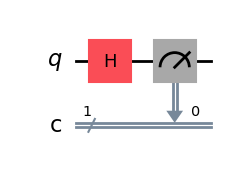

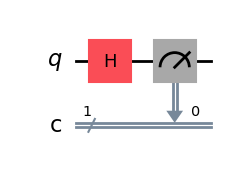

In [3]:
# ── 1c.  Qiskit QuantumCircuit diagram ───────────────────────────────────────
qc_superpos_meas = to_qiskit_circuit(SPH_SUPERPOS_MEAS)
qc_superpos_meas.draw('mpl', style='iqp', fold=-1)


State vector: [0.70710678+0.j 0.70710678+0.j]


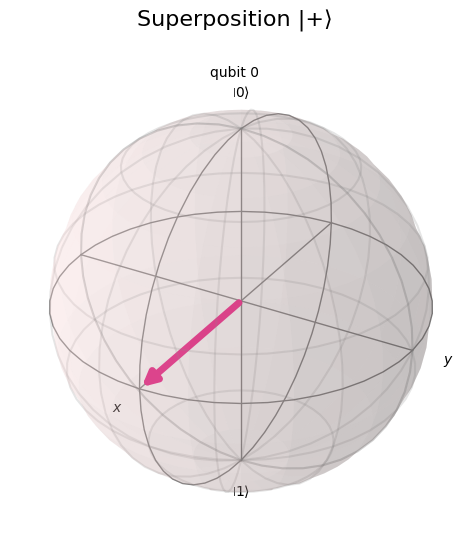

In [4]:
# ── 1d.  Bloch sphere — state BEFORE measurement ─────────────────────────────
# The |+⟩ state sits on the equator of the Bloch sphere at the +X pole.
sv_superpos = statevector_from(SPH_SUPERPOS)
print(f"State vector: {sv_superpos.data}")

fig = plot_bloch_multivector(sv_superpos, title="Superposition |+⟩")
plt.tight_layout()
plt.show()


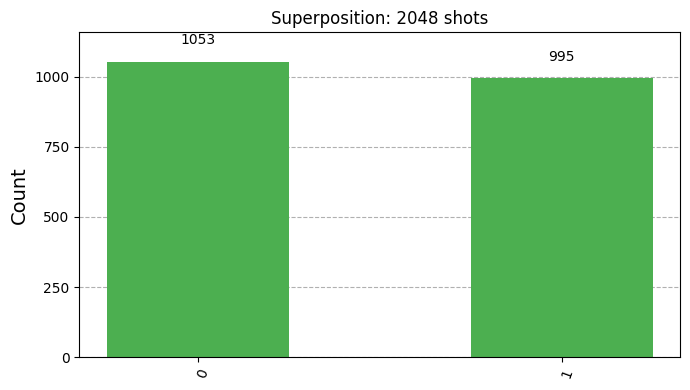

Counts: {'0': 1053, '1': 995}
  |0⟩   1053 / 2048  (51.4%)
  |1⟩    995 / 2048  (48.6%)


In [5]:
# ── 1e.  Shot simulation — 50/50 histogram ───────────────────────────────────
fig, counts = run_shots(qc_superpos_meas, shots=2048, title="Superposition: 2048 shots")
plt.show()

print("Counts:", counts)
total = sum(counts.values())
for state, n in sorted(counts.items()):
    print(f"  |{state}⟩  {n:5d} / {total}  ({100 * n / total:.1f}%)")


---
## 2  ·  Bell State (Two-Qubit Entanglement)

The Bell state $|\Phi^+\rangle$ is the archetypal maximally entangled two-qubit state:

$$|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$$

**Circuit**: H on qubit 0, then CNOT (q0 = control → q1 = target).  
In SpinachLang the `FCX` gate acts on the **control** qubit and names the **target** as its argument:

```spinach
q 0 -> H | FCX(q 1)   # q0 = control, q1 = target
* -> M
```


In [6]:
# ── 2a.  Spinach source ───────────────────────────────────────────────────────
SPH_BELL      = "q 0 -> H | FCX(q 1)"
SPH_BELL_MEAS = "q 0 -> H | FCX(q 1)\n* -> M"

print("Spinach source (with measurement):")
print("\n".join("  " + l for l in SPH_BELL_MEAS.splitlines()))

tket_bell = to_tket_circuit(SPH_BELL_MEAS)
print("\nPyTKET circuit:")
show_tket_circuit(tket_bell)


Spinach source (with measurement):
  q 0 -> H | FCX(q 1)
  * -> M

PyTKET circuit:


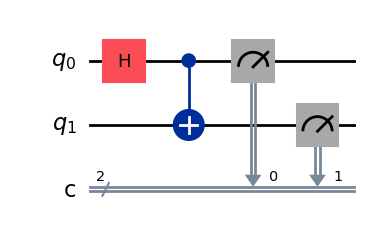

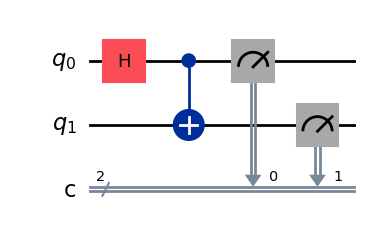

In [7]:
# ── 2b.  Qiskit QuantumCircuit diagram ───────────────────────────────────────
qc_bell_meas = to_qiskit_circuit(SPH_BELL_MEAS)
qc_bell_meas.draw('mpl', style='iqp', fold=-1)


Non-zero amplitudes:
  |00⟩  amp = 0.7071+0.0000j  prob = 0.5000
  |11⟩  amp = 0.7071+0.0000j  prob = 0.5000


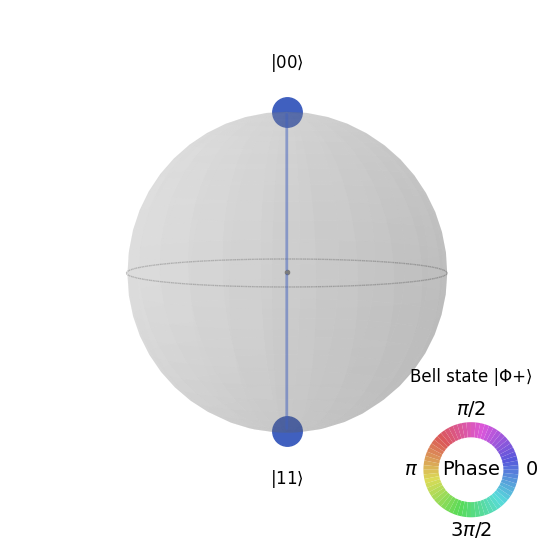

In [8]:
# ── 2c.  Q-sphere — entangled state before measurement ──────────────────────
# Equal amplitudes at |00⟩ and |11⟩ (north/south poles of the Q-sphere).
sv_bell = statevector_from(SPH_BELL)
print("Non-zero amplitudes:")
for basis, amp in zip(["00","01","10","11"], sv_bell.data):
    if abs(amp) > 1e-9:
        print(f"  |{basis}⟩  amp = {amp:.4f}  prob = {abs(amp)**2:.4f}")

fig = plot_state_qsphere(sv_bell)
plt.title("Bell state |Φ+⟩")
plt.show()


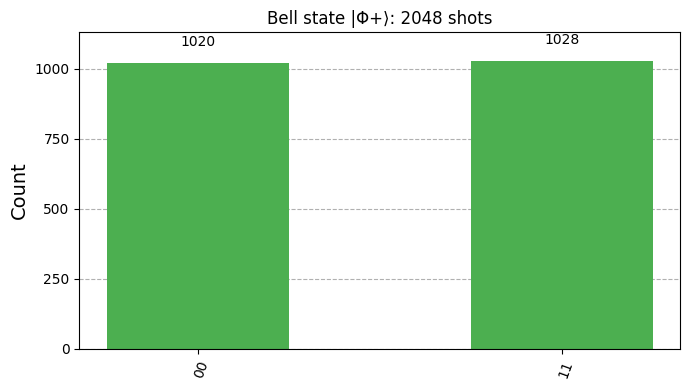

Counts: {'00': 1020, '11': 1028}
✅ Only |00⟩ and |11⟩ observed — entanglement confirmed.


In [9]:
# ── 2d.  Shot simulation — only |00⟩ and |11⟩ ever appear ──────────────────
fig, counts = run_shots(qc_bell_meas, shots=2048, title="Bell state |Φ+⟩: 2048 shots")
plt.show()
print("Counts:", counts)

# Verify: entanglement means |01⟩ and |10⟩ are forbidden.
unexpected = {k for k in counts if k not in ("00", "11")}
if unexpected:
    print(f"⚠️  Unexpected states: {unexpected}")
else:
    print("✅ Only |00⟩ and |11⟩ observed — entanglement confirmed.")


---
## 3  ·  GHZ State (Three-Qubit Entanglement)

The Greenberger–Horne–Zeilinger (GHZ) state generalises the Bell state to three qubits:

$$|\text{GHZ}\rangle = \frac{|000\rangle + |111\rangle}{\sqrt{2}}$$

**Circuit**: H on qubit 0, then chain two CNOTs: 0→1 and 0→2.

```spinach
q 0 -> H | FCX(q 1) | FCX(q 2)
* -> M
```


In [10]:
# ── 3a.  Spinach source ───────────────────────────────────────────────────────
SPH_GHZ      = "q 0 -> H | FCX(q 1) | FCX(q 2)"
SPH_GHZ_MEAS = SPH_GHZ + "\n* -> M"

print("Spinach source:")
print("\n".join("  " + l for l in SPH_GHZ_MEAS.splitlines()))

tket_ghz = to_tket_circuit(SPH_GHZ_MEAS)
print("\nPyTKET circuit:")
show_tket_circuit(tket_ghz)


Spinach source:
  q 0 -> H | FCX(q 1) | FCX(q 2)
  * -> M

PyTKET circuit:


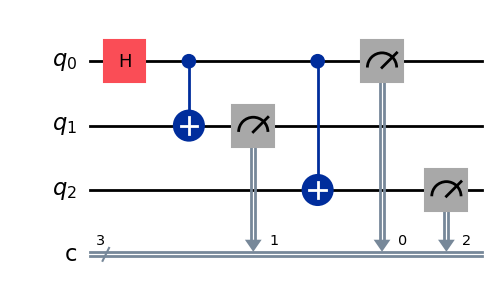

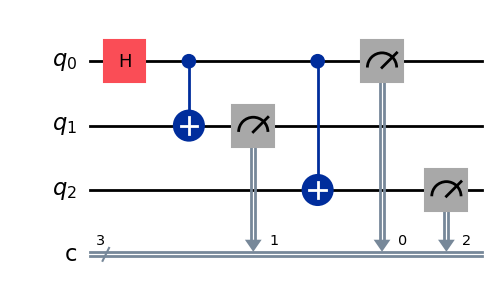

In [11]:
# ── 3b.  Qiskit QuantumCircuit diagram ───────────────────────────────────────
qc_ghz_meas = to_qiskit_circuit(SPH_GHZ_MEAS)
qc_ghz_meas.draw('mpl', style='iqp', fold=-1)


Non-zero amplitudes:
  |000⟩  0.7071+0.0000j
  |111⟩  0.7071+0.0000j


/tmp/nix-shell-222730-3143768688/ipykernel_233375/604674341.py:12: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


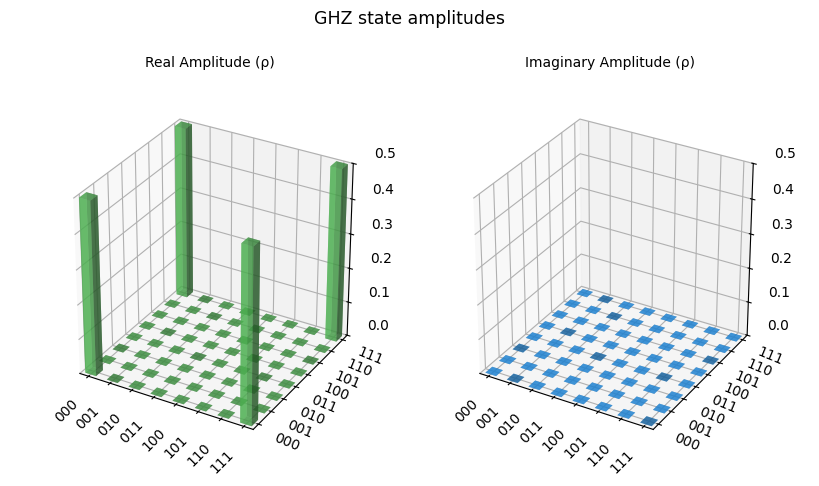

In [12]:
# ── 3c.  State-city plot — amplitudes before measurement ─────────────────────
sv_ghz = statevector_from(SPH_GHZ)
print("Non-zero amplitudes:")
basis_labels = [f"{i:03b}" for i in range(8)]
for label, amp in zip(basis_labels, sv_ghz.data):
    if abs(amp) > 1e-9:
        print(f"  |{label}⟩  {amp:.4f}")

fig = plot_state_city(sv_ghz, title="GHZ state amplitudes",
                     figsize=(8, 5), alpha=0.6,
                     color=["#4CAF50", "#2196F3"])
plt.tight_layout()
plt.show()


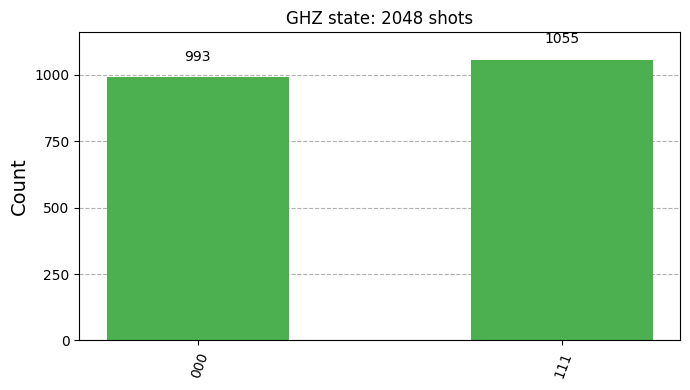

Counts: {'000': 993, '111': 1055}
✅ Only |000⟩ and |111⟩ observed — 3-qubit GHZ entanglement confirmed.


In [13]:
# ── 3d.  Shot simulation — only |000⟩ and |111⟩ ──────────────────────────────
fig, counts = run_shots(qc_ghz_meas, shots=2048, title="GHZ state: 2048 shots")
plt.show()
print("Counts:", counts)

unexpected = {k for k in counts if k not in ("000", "111")}
if unexpected:
    print(f"⚠️  Unexpected states: {unexpected}")
else:
    print("✅ Only |000⟩ and |111⟩ observed — 3-qubit GHZ entanglement confirmed.")


---
## 4  ·  Deutsch's Algorithm

Deutsch's algorithm decides whether a boolean function $f:\{0,1\}\to\{0,1\}$ is
*constant* (same output for both inputs) or *balanced* (different outputs) using only
a **single** quantum oracle query — versus two classical queries.

**Measurement result:**
- Qubit 0 = `0` → $f$ is **constant**  
- Qubit 0 = `1` → $f$ is **balanced**

The oracle used here implements **f(x) = x** (balanced).

```spinach
q 1 -> X              # ancilla to |1⟩
[q 0, q 1] -> H       # superposition on both qubits
q 1 -> CX(q 0)        # oracle: f(x)=x  — q0 is control, q1 is target
q 0 -> H | M          # interference + measure
```


In [14]:
# ── 4a.  Spinach source ───────────────────────────────────────────────────────
SPH_DEUTSCH = "\n".join([
    "# Deutsch's algorithm",
    "q 1 -> X",            # ancilla |1⟩
    "[q 0, q 1] -> H",     # Hadamard on both
    "q 1 -> CX(q 0)",      # oracle: f(x) = x  (balanced)
    "q 0 -> H | M",        # interference + measure
])

print("Spinach source:")
print("\n".join("  " + l for l in SPH_DEUTSCH.splitlines()))

tket_deutsch = to_tket_circuit(SPH_DEUTSCH)
print("\nPyTKET circuit:")
show_tket_circuit(tket_deutsch)


Spinach source:
  # Deutsch's algorithm
  q 1 -> X
  [q 0, q 1] -> H
  q 1 -> CX(q 0)
  q 0 -> H | M

PyTKET circuit:


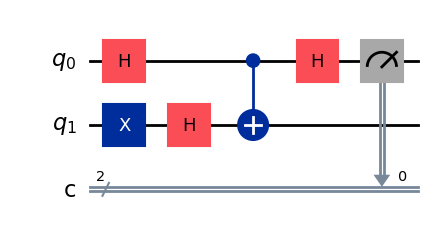

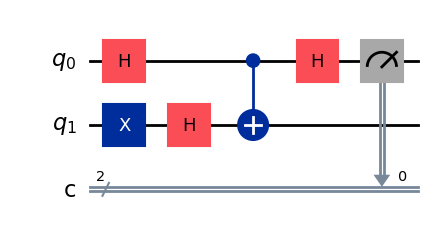

In [15]:
# ── 4b.  Qiskit QuantumCircuit diagram ───────────────────────────────────────
qc_deutsch = to_qiskit_circuit(SPH_DEUTSCH)
qc_deutsch.draw('mpl', style='iqp', fold=-1)


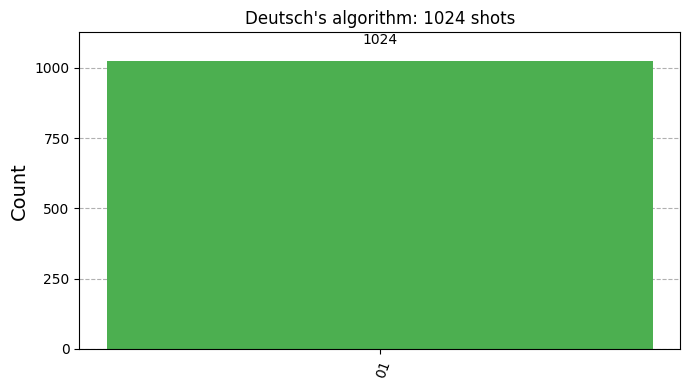

Counts: {'01': 1024}


In [16]:
# ── 4c.  Shot simulation ─────────────────────────────────────────────────────
fig, counts = run_shots(qc_deutsch, shots=1024, title="Deutsch's algorithm: 1024 shots")
plt.show()
print("Counts:", counts)


In [17]:
# ── 4d.  Interpret result ────────────────────────────────────────────────────
# Qiskit classical-register ordering: rightmost bit = qubit with lowest index.
# Qubit 0 is the decision qubit; only the last character encodes the answer.
q0_bits = {state[-1]: n for state, n in counts.items()}

dominant = max(q0_bits, key=q0_bits.get)
verdict = "BALANCED  (f(0) ≠ f(1))" if dominant == "1" else "CONSTANT  (f(0) = f(1))"

print("Qubit-0 measurement:")
for bit, n in sorted(q0_bits.items()):
    bar = "█" * int(40 * n / sum(q0_bits.values()))
    print(f"  |{bit}⟩  {bar} {n}")

print(f"\n🔬 Deutsch's verdict: function is {verdict}")
print("   Expected: BALANCED (oracle = f(x) = x)")
assert dominant == "1", "Deutsch algorithm gave wrong answer!"
print("✅ Correct.")


Qubit-0 measurement:
  |1⟩  ████████████████████████████████████████ 1024

🔬 Deutsch's verdict: function is BALANCED  (f(0) ≠ f(1))
   Expected: BALANCED (oracle = f(x) = x)
✅ Correct.


---
## Summary

This notebook demonstrated SpinachLang's end-to-end pipeline:

1. **Write** compact quantum programs in the Spinach DSL (`.sph` syntax).
2. **Compile** to a PyTKET `Circuit` with `to_tket_circuit()` — TKET's IR enables
   backend-agnostic optimisation.
3. **Convert** to a Qiskit `QuantumCircuit` with `to_qiskit_circuit()` in one call,
   giving access to the full IBM Quantum ecosystem.
4. **Simulate** locally with `qiskit_aer.AerSimulator` and visualise with Qiskit's
   built-in plotting tools.

### Going further

| Goal | Code |
|------|------|
| Run on real IBM hardware | `from qiskit_ibm_runtime import QiskitRuntimeService` |
| Export to OpenQASM 2.0 | `spinachlang.compile_code(sph, "qasm")` |
| Export to Cirq / Quil / Braket | `spinachlang.to_cirq_circuit(sph)` etc. |
| Noise-model simulation | `AerSimulator.from_backend(noise_model)` |
| Circuit optimisation | `pytket.passes.FullPeepholeOptimise().apply(tket_circuit)` |

See the [SpinachLang repository](https://github.com/spinachlang/spinachlang) and
the [PyTKET docs](https://cqcl.github.io/tket/pytket/api/) for more.
